<a href="https://colab.research.google.com/github/Linda-Mohamed/plant-disease-detection-cnn/blob/main/plant_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages
!pip install -q tensorflow opencv-python matplotlib seaborn pandas kagglehub

In [1]:
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2D, Dense , Flatten
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub
import os
import cv2

2.19.0


In [2]:
# Download the image dataset
dataset_dir = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# List all files in the dataset directory
image_files = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Total images found: 6092
Sample images: ['/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight/3b34322e-e2ad-4023-bf76-f290fb2455a1___GHLB_PS Leaf 52 Day 18_flipLR.jpg', '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight/1cb5d336-3649-49bf-aa9a-72950067b8b0___GHLB_PS Leaf 12 Day 9_flipLR.jpg', '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight/4bf424a2-b275-4ac0-968c-fe229136f10d___GHLB_PS Leaf 2.5 Day 16.jpg', '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight/48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS Leaf 23.7 Day 13.jpg', '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant D

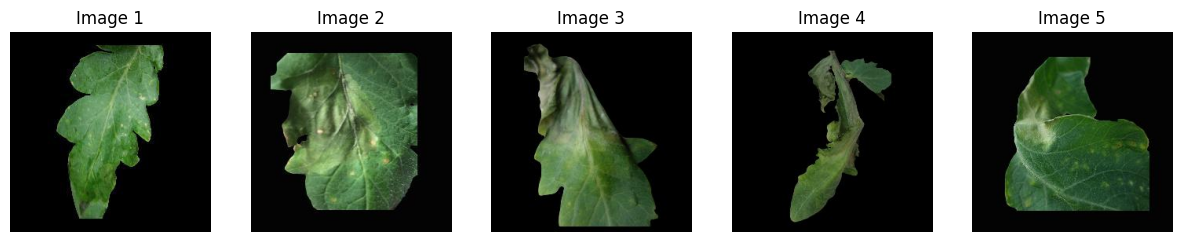

In [3]:
# Collect all image file paths from subdirectories
image_files = []
for root, _, files in os.walk(dataset_dir):
    for f in files:
        if f.endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, f))

print("Total images found:", len(image_files))
print("Sample images:", image_files[:5])  # Print a few file paths

# Function to display images
def show_images(images, num=5):
    plt.figure(figsize=(15, 5))
    for i in range(min(num, len(images))):
        img = cv2.imread(images[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i+1}")
    plt.show()

# Show 5 sample images
if image_files:
    show_images(image_files, num=5)
else:
    print("No images found in the dataset!")

**data preprocessing : training images**

In [4]:
print("Dataset directory:", dataset_dir)
print("\nFolder structure:")
for root, dirs, files in os.walk(dataset_dir):
    print(f"📂 {root}")
    for d in dirs:
        print(f"   📁 {d}")
    for f in files[:5]:  # Show first 5 files
        print(f"   📄 {f}")
    print()


Dataset directory: /kaggle/input/new-plant-diseases-dataset

Folder structure:
📂 /kaggle/input/new-plant-diseases-dataset
   📁 New Plant Diseases Dataset(Augmented)
   📁 new plant diseases dataset(augmented)
   📁 test

📂 /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)
   📁 New Plant Diseases Dataset(Augmented)

📂 /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
   📁 valid
   📁 train

📂 /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
   📁 Tomato___Late_blight
   📁 Tomato___healthy
   📁 Grape___healthy
   📁 Orange___Haunglongbing_(Citrus_greening)
   📁 Soybean___healthy
   📁 Squash___Powdery_mildew
   📁 Potato___healthy
   📁 Corn_(maize)___Northern_Leaf_Blight
   📁 Tomato___Early_blight
   📁 Tomato___Septoria_leaf_spot
   📁 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   📁 Strawberry___Leaf_scorch
   📁 Peach___

In [5]:
train_dir = os.path.join(dataset_dir, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train")

# Check if the path exists
if not os.path.exists(train_dir):
    print(f" Error: Directory not found -> {train_dir}")
else:
    print(f" Found training directory: {train_dir}")

    # Load dataset using the correct path
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=32,
        image_size=(128, 128),
        shuffle=True,
    )

    print(" Dataset loaded successfully!")


 Found training directory: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Found 70295 files belonging to 38 classes.
 Dataset loaded successfully!


**Data preprocessing : validation images**

In [6]:
# Define the validation directory
valid_dir = os.path.join(dataset_dir, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "valid")
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
# Print the path
print("Validation directory:", valid_dir)

# Check if the directory exists
if os.path.exists(valid_dir):
    print("Directory exists!")
else:
    print("Directory does not exist. Please check the path.")

Found 17572 files belonging to 38 classes.
Validation directory: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Directory exists!


**Building the model**

1.Convolution Max Pooling Layer : more con layers = more extraction of features ==>resolve underfitting

In [7]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3] ,kernel_regularizer=regularizers.l2(0.001)))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.5))


cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Flatten())
#add dense layer = hidden layer
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu')) #units = nb of neurons
cnn.add(tf.keras.layers.Dropout(0.5)) #To avoid overfitting
#output_layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax')) #probability of each class in each neuron

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compiling Model**

In [8]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
#see all parameters of model
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

**Model training**

In [10]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,
    restore_best_weights=True  # Restore the best model weights
)

# Define ModelCheckpoint callback
checkpoint = ModelCheckpoint(
    'best_model.h5',     # Save the best model to this file
    monitor='val_loss',  # Monitor validation loss
    save_best_only=True  # Save only the best model
)


In [12]:
!nvidia-smi

Mon Mar 23 00:27:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             28W /   70W |     233MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
# Train the Model
history = cnn.fit(
    training_set,  # Training data
    epochs=40,     # Number of epochs
    validation_data=validation_set,
    callbacks=[early_stopping, checkpoint]  # Callbacks
)

Epoch 1/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0294 - loss: 4.9534

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 286s 120ms/step - accuracy: 0.0427 - loss: 4.2927 - val_accuracy: 0.1935 - val_loss: 3.8522
Epoch 2/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2351 - loss: 3.2316

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 141s 64ms/step - accuracy: 0.3172 - loss: 2.8462 - val_accuracy: 0.5282 - val_loss: 2.3372
Epoch 3/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5205 - loss: 1.9922

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.5659 - loss: 1.8132 - val_accuracy: 0.6162 - val_loss: 1.6972
Epoch 4/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6790 - loss: 1.3639

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.7044 - loss: 1.2591 - val_accuracy: 0.7564 - val_loss: 1.1513
Epoch 5/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7719 - loss: 1.0013

...

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9616 - loss: 0.2452 - val_accuracy: 0.9344 - val_loss: 0.3371
Epoch 21/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 197s 64ms/step - accuracy: 0.9648 - loss: 0.2366 - val_accuracy: 0.9336 - val_loss: 0.3459
Epoch 22/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9670 - loss: 0.2268

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9658 - loss: 0.2301 - val_accuracy: 0.9394 - val_loss: 0.3154
Epoch 23/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 151s 69ms/step - accuracy: 0.9676 - loss: 0.2221 - val_accuracy: 0.9188 - val_loss: 0.3859
Epoch 24/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9688 - loss: 0.2176

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.9686 - loss: 0.2161 - val_accuracy: 0.9557 - val_loss: 0.2616
Epoch 25/40
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9687 - loss: 0.2157

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9694 - loss: 0.2128 - val_accuracy: 0.9575 - val_loss: 0.2446
Epoch 26/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9699 - loss: 0.2096 - val_accuracy: 0.9367 - val_loss: 0.3210
Epoch 27/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9697 - loss: 0.2081 - val_accuracy: 0.9429 - val_loss: 0.3120
Epoch 28/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9732 - loss: 0.2000 - val_accuracy: 0.9309 - val_loss: 0.3472
Epoch 29/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 151s 69ms/step - accuracy: 0.9738 - loss: 0.1951 - val_accuracy: 0.9384 - val_loss: 0.3178
Epoch 30/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9730 - loss: 0.1970 - val_accuracy: 0.9225 - val_loss: 0.3829
Epoch 31/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 198s 64ms/step - accuracy: 0.9751 - loss: 0.1880 - val_accuracy: 0.9339 - val_loss: 0.3540
Epoch 32/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.97

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 67ms/step - accuracy: 0.9754 - loss: 0.1859 - val_accuracy: 0.9610 - val_loss: 0.2293
Epoch 34/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 152s 69ms/step - accuracy: 0.9758 - loss: 0.1841 - val_accuracy: 0.9375 - val_loss: 0.3159
Epoch 35/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9767 - loss: 0.1783 - val_accuracy: 0.9274 - val_loss: 0.3434
Epoch 36/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 67ms/step - accuracy: 0.9761 - loss: 0.1795 - val_accuracy: 0.9527 - val_loss: 0.2666
Epoch 37/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9776 - loss: 0.1766 - val_accuracy: 0.9557 - val_loss: 0.2436
Epoch 38/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9783 - loss: 0.1733 - val_accuracy: 0.9526 - val_loss: 0.2660
Epoch 39/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 202s 67ms/step - accuracy: 0.9791 - loss: 0.1701 - val_accuracy: 0.9615 - val_loss: 0.2329
Epoch 40/40
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.97

In [14]:
#Evaluation of the model
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.9769 - loss: 0.1774
Training accuracy: 0.976854681968689


In [15]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.9610 - loss: 0.2293
Validation accuracy: 0.9610175490379333


**Saving Model**

In [18]:
cnn.save('trained_plant_disease_model.keras')

In [19]:
history.history #Return Dictionary of history

{'accuracy': [0.04267728701233864,
  0.3172203004360199,
  0.5658723711967468,
  0.7044455409049988,
  0.785190999507904,
  0.8380966186523438,
  0.8686108589172363,
  0.8933494687080383,
  0.9081442356109619,
  0.9224411249160767,
  0.9298242926597595,
  0.938174843788147,
  0.9420726895332336,
  0.9475923180580139,
  0.9501102566719055,
  0.9536809325218201,
  0.9566256403923035,
  0.958816409111023,
  0.9608080387115479,
  0.9616473317146301,
  0.9648054838180542,
  0.9658297300338745,
  0.9675794839859009,
  0.9686322212219238,
  0.9693719148635864,
  0.9698556065559387,
  0.969684898853302,
  0.9731702208518982,
  0.9737676978111267,
  0.9730279445648193,
  0.9751476049423218,
  0.9752187132835388,
  0.9754178524017334,
  0.9758161902427673,
  0.9767124056816101,
  0.9760580658912659,
  0.9776228666305542,
  0.9783199429512024,
  0.9790596961975098,
  0.9781919121742249],
 'loss': [4.292678356170654,
  2.8462207317352295,
  1.8131871223449707,
  1.2590967416763306,
  0.94803065061

In [20]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(history.history,f)

In [21]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


**Accuracy Visualization**

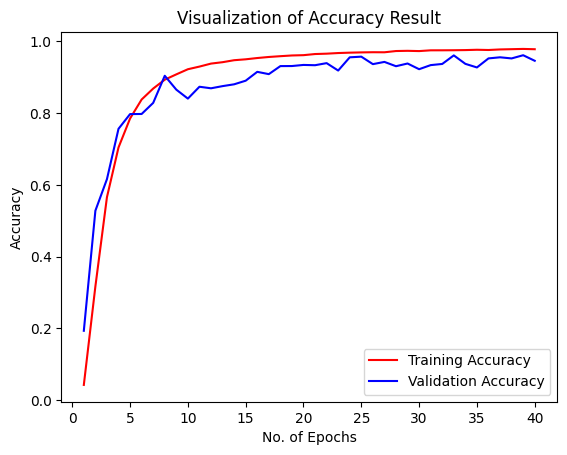

In [22]:
# Create epochs array dynamically
epochs = range(1, len(history.history['accuracy']) + 1)

# Plot training and validation accuracy
plt.plot(epochs, history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], color='blue', label='Validation Accuracy')

# Add labels and title
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result')
plt.legend()

# Show the plot
plt.show()

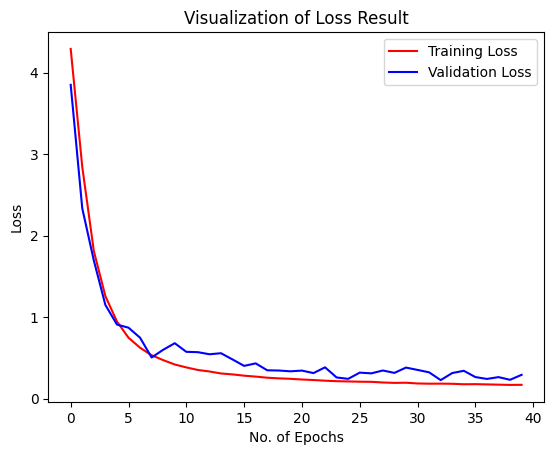

In [23]:
plt.plot(history.history['loss'], color='red', label='Training Loss')
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')

# Labels and Title
plt.xlabel('No. of Epochs')
plt.ylabel('Loss')
plt.title('Visualization of Loss Result')
plt.legend()

# Show the plot
plt.show()


**Testing**

In [24]:
# Check if model exists
model_path = "trained_plant_disease_model.keras"
print(f"Model exists: {os.path.exists(model_path)}")

Model exists: True


In [25]:
# Load the trained model
model = load_model(model_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,685,526 (59.84 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,842,764 (29.92 MB)

In [27]:
from google.colab import drive
drive.mount('/content/drive')

# Copy the model to Google Drive
!cp trained_plant_disease_model.keras '/content/drive/MyDrive/pfe/'

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Full path to the test directory
test_dir = "/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test"

# Example: Load "PotatoHealthy2.JPG"
image_filename = "PotatoHealthy2.JPG"
image_path = os.path.join(test_dir, image_filename)

# Verify file exists
if not os.path.exists(image_path):
    print(f"Error: {image_path} does not exist!")
else:
    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print("Failed to load image (corrupted or invalid format)")
    else:
        # Convert BGR to RGB for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()

In [ ]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

In [ ]:
prediction = model.predict(input_arr)
prediction,prediction.shape

In [ ]:
result_index = np.argmax(prediction)
result_index

In [ ]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [ ]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
model_prediction

In [ ]:
from google.colab import files
files.download('trained_plant_disease_model.keras')